In [1]:
import pandas as pd
import cv2
import os
import ast
from tqdm import tqdm

# Cấu hình đường dẫn
CSV_PATH = "/kaggle/input/datasets/phhasian0710/za-traffic-2020/za_traffic_2020/traffic_train/annotation.csv"
IMAGES_2020_DIR = "/kaggle/input/datasets/phhasian0710/za-traffic-2020/za_traffic_2020/traffic_train/images"
CNN_DATASET_DIR = "/kaggle/working/cnn_dataset/train"

os.makedirs(CNN_DATASET_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
grouped = df.groupby('file_name')

print("🚀 Bắt đầu Crop ảnh 2020 tạo Dataset CNN...")
count_cropped = 0

for file_name, group in tqdm(grouped):
    img_path = os.path.join(IMAGES_2020_DIR, str(file_name))
    if not os.path.exists(img_path): continue
        
    img = cv2.imread(img_path)
    if img is None: continue
        
    for idx, row in group.iterrows():
        class_id = int(row['category_id'])
        
        # Đọc mảng [x_min, y_min, w, h] từ chuẩn COCO
        bbox = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
        x, y, w, h = map(int, bbox)
        
        # Rào lỗi tọa độ tràn viền
        y1, y2 = max(0, y), min(img.shape[0], y + h)
        x1, x2 = max(0, x), min(img.shape[1], x + w)
        
        # Cắt sát biển báo (Cropping)
        cropped_img = img[y1:y2, x1:x2]
        
        if cropped_img.size == 0: continue
            
        # Ép về chuẩn CNN: 224x224
        resized_img = cv2.resize(cropped_img, (224, 224))
        
        # Tạo thư mục theo Class ID (vd: /cnn_dataset/train/0)
        class_dir = os.path.join(CNN_DATASET_DIR, str(class_id))
        os.makedirs(class_dir, exist_ok=True)
        
        # Lưu file
        save_path = os.path.join(class_dir, f"{file_name.split('.')[0]}_{idx}.jpg")
        cv2.imwrite(save_path, resized_img)
        count_cropped += 1

print(f"✅ Đã trích xuất thành công {count_cropped} ảnh biển báo sạch (224x224) chia vào các thư mục Class!")

🚀 Bắt đầu Crop ảnh 2020 tạo Dataset CNN...


100%|██████████| 4500/4500 [03:12<00:00, 23.37it/s]

✅ Đã trích xuất thành công 11000 ảnh biển báo sạch (224x224) chia vào các thư mục Class!


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# 1. Định nghĩa 2 luồng xử lý ảnh RIÊNG BIỆT
# Luồng Train: Cố tình làm khó model (Xoay, đổi màu, thêm nhiễu)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), # Xoay ngẫu nhiên
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Đổi độ sáng/tương phản
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Luồng Val (Thi cử): Tuyệt đối giữ nguyên bản, chỉ Resize và Normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Tạo 2 Dataset trỏ về CÙNG MỘT thư mục gốc (chỉ chứa ảnh crop nguyên bản, xóa sạch ảnh đã augment lưu trên đĩa)
CNN_DATASET_DIR = "/kaggle/working/cnn_dataset/train" # Thư mục này giờ chỉ nên chứa ảnh Crop gốc
full_train_dataset = datasets.ImageFolder(root=CNN_DATASET_DIR, transform=train_transform)
full_val_dataset = datasets.ImageFolder(root=CNN_DATASET_DIR, transform=val_transform)

# 3. Chia index 80/20 cực chuẩn (Không để lọt index qua lại)
num_samples = len(full_train_dataset)
indices = list(range(num_samples))
np.random.shuffle(indices)
split = int(np.floor(0.2 * num_samples))

train_idx, val_idx = indices[split:], indices[:split]

# 4. Gắn Index vào đúng Dataset
train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_val_dataset, val_idx)

# Nạp vào DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✅ Setup an toàn: Train ({len(train_dataset)} ảnh có Augment) - Val ({len(val_dataset)} ảnh nguyên bản)")

✅ Setup an toàn: Train (8800 ảnh có Augment) - Val (2200 ảnh nguyên bản)


In [3]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# ==========================================
# KHẮC PHỤC LỖI: Tự động lấy kích thước tập dữ liệu
# ==========================================
train_size = len(train_dataset)
val_size = len(val_dataset)
print(f"📦 Đã nạp kích thước dữ liệu: Train={train_size}, Val={val_size}")

# ==========================================
# 1. KHỞI TẠO MODEL: FINE-TUNING TOÀN PHẦN (UNFREEZE ALL)
# ==========================================
print("Đang khởi tạo MobileNetV2 (Chế độ Fine-Tuning toàn phần)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model với trọng số ImageNet
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# BƯỚC NGOẶT: MỞ KHÓA TOÀN BỘ TRỌNG SỐ ĐỂ TỰ HỌC LẠI
for param in model.parameters():
    param.requires_grad = True

# Điều chỉnh lớp cuối cùng cho 103 class của Zalo & 2026
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 103)
model = model.to(device)

# Loss và Optimizer (Sử dụng LR = 1e-4 để không phá hỏng trọng số gốc)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# ==========================================
# 2. CẤU HÌNH HUẤN LUYỆN NÂNG CAO
# ==========================================
EPOCHS = 20
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

# Kéo LR hiện tại ra để theo dõi
current_lr = optimizer.param_groups[0]['lr']

# Cơ chế giảm LR: Nếu Val Loss không giảm sau 2 epoch, giảm LR đi 5 lần
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

print(f"🔥 BẮT ĐẦU HUẤN LUYỆN NÂNG CAO ({EPOCHS} EPOCHS) - Bắt đầu với LR: {current_lr}")

# ==========================================
# 3. VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
# ==========================================
for epoch in range(EPOCHS):
    start_time = time.time()
    
    # PHA TRAIN
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    
    epoch_acc = running_corrects.double() / train_size
    epoch_loss = running_loss / train_size

    # PHA VAL
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / val_size
    val_epoch_acc = val_corrects.double() / val_size
    
    # In báo cáo Epoch
    print(f"Epoch {epoch+1:02d} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f}")

    # Cập nhật Scheduler dựa trên Val Loss
    scheduler.step(val_epoch_loss)
    
    # Tự động check và báo cáo nếu LR bị giảm
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < current_lr:
        print(f"   📉 CẢNH BÁO: Learning Rate đã tự động giảm từ {current_lr} xuống {new_lr}")
        current_lr = new_lr

    # Lưu model tốt nhất
    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), '/kaggle/working/best_mobilenet_v2.pth')

# ==========================================
# 4. TRUY XUẤT TOP 5 CLASS SAI NHIỀU NHẤT
# ==========================================
print("\n🔍 ĐANG PHÂN TÍCH TOP 5 CLASS CÓ ĐỘ CHÍNH XÁC THẤP NHẤT...")
model.load_state_dict(best_model_wts) # Load lại tạ xịn nhất để test
model.eval()

class_correct = list(0. for i in range(103))
class_total = list(0. for i in range(103))

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        c = (preds == labels).squeeze()
        
        if c.dim() == 0:
            c = c.unsqueeze(0)
            
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# Tính toán % và lọc top 5
class_accs = []
for i in range(103):
    if class_total[i] > 0:
        acc = 100 * class_correct[i] / class_total[i]
        class_accs.append((i, acc, class_total[i]))

class_accs.sort(key=lambda x: x[1])

print("-" * 30)
print(f"{'Class ID':<10} | {'Accuracy':<10} | {'Total Samples'}")
for i in range(min(5, len(class_accs))):
    cid, acc, total = class_accs[i]
    print(f"{cid:<10} | {acc:>8.2f}% | {int(total):>5}")
print("-" * 30)

📦 Đã nạp kích thước dữ liệu: Train=8800, Val=2200
Đang khởi tạo MobileNetV2 (Chế độ Fine-Tuning toàn phần)...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 165MB/s]


🔥 BẮT ĐẦU HUẤN LUYỆN NÂNG CAO (20 EPOCHS) - Bắt đầu với LR: 0.0001
Epoch 01 | Train Acc: 0.8175 | Val Acc: 0.9418 | Val Loss: 0.2210
Epoch 02 | Train Acc: 0.9408 | Val Acc: 0.9486 | Val Loss: 0.1823
Epoch 03 | Train Acc: 0.9555 | Val Acc: 0.9577 | Val Loss: 0.1488
Epoch 04 | Train Acc: 0.9650 | Val Acc: 0.9582 | Val Loss: 0.1473
Epoch 05 | Train Acc: 0.9715 | Val Acc: 0.9591 | Val Loss: 0.1376
Epoch 06 | Train Acc: 0.9773 | Val Acc: 0.9618 | Val Loss: 0.1431
Epoch 07 | Train Acc: 0.9792 | Val Acc: 0.9627 | Val Loss: 0.1366
Epoch 08 | Train Acc: 0.9799 | Val Acc: 0.9605 | Val Loss: 0.1436
Epoch 09 | Train Acc: 0.9819 | Val Acc: 0.9677 | Val Loss: 0.1402
Epoch 10 | Train Acc: 0.9872 | Val Acc: 0.9664 | Val Loss: 0.1369
   📉 CẢNH BÁO: Learning Rate đã tự động giảm từ 0.0001 xuống 2e-05
Epoch 11 | Train Acc: 0.9914 | Val Acc: 0.9673 | Val Loss: 0.1371
Epoch 12 | Train Acc: 0.9915 | Val Acc: 0.9664 | Val Loss: 0.1400
Epoch 13 | Train Acc: 0.9923 | Val Acc: 0.9650 | Val Loss: 0.1401
   📉 CẢN

⏳ Đang load model MobileNetV2 best_mobilenet_v2.pth...
🚀 Đang chạy dự đoán trên 6 ảnh Validation ngẫu nhiên...


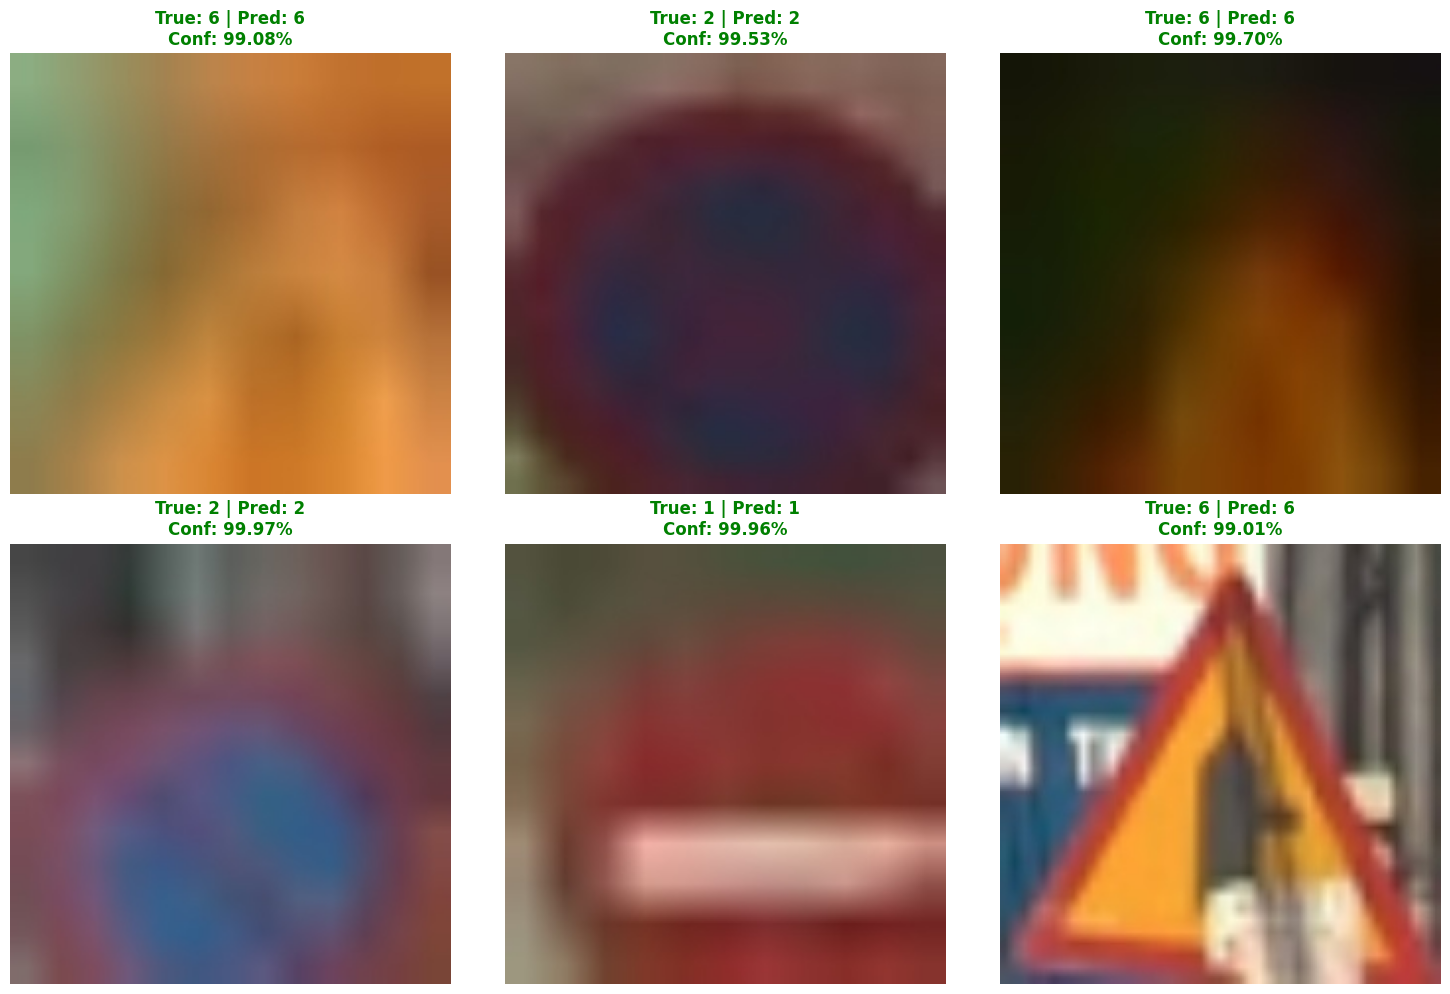

In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

# ==========================================
# 1. KHỞI TẠO VÀ LOAD TRỌNG SỐ TỐT NHẤT
# ==========================================
print("⏳ Đang load model MobileNetV2 best_mobilenet_v2.pth...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild cấu trúc model
model_test = models.mobilenet_v2(weights=None)
num_ftrs = model_test.classifier[1].in_features
model_test.classifier[1] = nn.Linear(num_ftrs, 103)

# Load trọng số
model_test.load_state_dict(torch.load('/kaggle/working/best_mobilenet_v2.pth'))
model_test = model_test.to(device)
model_test.eval() # Bật chế độ inference

# Pipeline tiền xử lý ảnh (BẮT BUỘC phải giống lúc Train)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# FIX: Lấy danh sách tên Class từ full_val_dataset
class_names = full_val_dataset.classes 

# ==========================================
# 2. HÀM INFERENCE CỐT LÕI
# ==========================================
def predict_image(image_path):
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform_test(img).unsqueeze(0).to(device) # Thêm batch dimension
    
    with torch.no_grad():
        outputs = model_test(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_class = class_names[predicted_idx.item()]
    return img, predicted_class, confidence.item() * 100

# ==========================================
# 3. CHẠY THỬ TRÊN 6 ẢNH NGẪU NHIÊN
# ==========================================
print("🚀 Đang chạy dự đoán trên 6 ảnh Validation ngẫu nhiên...")

# Trích xuất đường dẫn file từ val_dataset (PyTorch Subset)
val_indices = val_dataset.indices
random_indices = random.sample(val_indices, 6)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    # FIX: Lấy đường dẫn ảnh thật từ full_val_dataset
    img_path, true_label_idx = full_val_dataset.samples[idx]
    true_class = class_names[true_label_idx]
    
    # Đưa vào model dự đoán
    img, pred_class, conf = predict_image(img_path)
    
    # Hiển thị
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    
    # Nếu đoán đúng hiện chữ Xanh, đoán sai hiện chữ Đỏ
    color = 'green' if true_class == pred_class else 'red'
    title_text = f"True: {true_class} | Pred: {pred_class}\nConf: {conf:.2f}%"
    
    plt.title(title_text, color=color, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
import os
import shutil
import time
from IPython.display import FileLink, display

# Cấu hình lại đường dẫn
source_dir = "/kaggle/working/cnn_dataset"
output_zip = "/kaggle/working/CNN_Final_Dataset" # Không ghi đuôi .zip ở đây

if os.path.exists(source_dir):
    print(f"📦 Đang nén folder {source_dir}...")
    # Nén folder
    shutil.make_archive(output_zip, 'zip', source_dir)
    
    # Ép hệ thống đợi 3 giây để đồng bộ file ra đĩa
    time.sleep(3)
    
    if os.path.exists(f"{output_zip}.zip"):
        print("✅ Nén thành công! Thử click vào link dưới đây:")
        # Dùng os.path.basename để tạo link tương đối, tránh lỗi 404
        display(FileLink(os.path.basename(f"{output_zip}.zip")))
        display(FileLink("best_mobilenet_v2.pth"))
    else:
        print("❌ File nén không tồn tại, có thể do hết dung lượng đĩa (Disk Space).")
else:
    print("❌ Không tìm thấy folder cnn_dataset!")

📦 Đang nén folder /kaggle/working/cnn_dataset...
✅ Nén thành công! Thử click vào link dưới đây:


/kaggle/working/CNN_Final_Dataset.zip

/kaggle/working/best_mobilenet_v2.pth